# covaudit demo: does conformal prediction keep its promise for every group?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simarsinghlamba/covaudit/blob/main/notebooks/demo.ipynb)

Conformal prediction promises that the true answer is inside its prediction set at least
90% of the time. That promise is an **average over everyone**. This notebook uses
**covaudit** to check it **group by group** on US Census data (ACSIncome, California 2018),
with exact confidence intervals, and then repairs it with **Mondrian** (per-group)
conformal prediction.

**How to run:** Runtime -> Run all. It takes about 3-5 minutes and downloads the
California Census file (about 270 MB) from census.gov.

In [1]:
import importlib
import importlib.util

from IPython import get_ipython

if importlib.util.find_spec("covaudit") is None:  # e.g. Colab: install from GitHub
    get_ipython().run_line_magic(
        "pip", 'install -q "git+https://github.com/simarsinghlamba/covaudit@v1.0.0"')
    importlib.invalidate_caches()
else:  # e.g. the project's Docker image: covaudit is already installed
    print("covaudit is already installed")

covaudit is already installed


## 1. The data

Predict whether a working adult earns more than $50,000. The groups we audit are race (`RAC1P`).

In [2]:
from pathlib import Path

from covaudit.data import RACE_NAMES, load_acs_income, split_indices

# Reuse the repository's data folder when it exists (Docker), otherwise download here.
root = "../data" if Path("../data/2018").exists() else "data"
X, y = load_acs_income("CA", "2018", root=root)
print(f"{len(X):,} people | share earning over $50k: {y.mean():.3f}")
X["RAC1P"].map(lambda c: RACE_NAMES[int(c)]).value_counts()

195,665 people | share earning over $50k: 0.411


,count
RAC1P,
White,121006
Asian,32709
Some other race,22793
Black,8557
Two or more races,8206
American Indian,1294
Native Hawaiian/PI,637
AI/AN tribes,450
Alaska Native,13


## 2. Train an ordinary model

Split 60% train / 20% calibration / 20% test with a fixed seed, then train gradient boosting. The model is deliberately ordinary: covaudit audits whatever model it is given.

In [3]:
from covaudit.model import train_model

s = split_indices(len(X), seed=0)
X_tr, y_tr = X.iloc[s["train"]], y.iloc[s["train"]]
X_cal, y_cal = X.iloc[s["cal"]], y.iloc[s["cal"]]
X_te, y_te = X.iloc[s["test"]], y.iloc[s["test"]]
model = train_model(X_tr, y_tr, seed=0)
print(f"test accuracy: {model.score(X_te, y_te):.4f}")

test accuracy: 0.8278


## 3. Split conformal prediction: one threshold for everyone

Score = 1 - probability of the true label. The threshold is the ceil((n+1)(1-alpha))-th smallest calibration score, and every label scoring at or below it goes into the prediction set.

In [4]:
from covaudit import SplitConformal, average_set_size, coverage

split = SplitConformal(model, alpha=0.1).calibrate(X_cal, y_cal)
split_sets = split.predict_sets(X_te)
print(f"threshold {split.threshold_:.4f}")
print(f"coverage {coverage(y_te, split_sets, model.classes_):.4f} (promise: 0.90)")
print(f"average set size {average_set_size(split_sets):.4f}")

threshold 0.6588
coverage 0.9032 (promise: 0.90)
average set size 1.1818


## 4. The audit: coverage for each race group

Each group gets an exact (Clopper-Pearson) 95% interval. **FAIL** means even the top of the interval is below 90%; **LOW** means below 90% but chance could explain it.

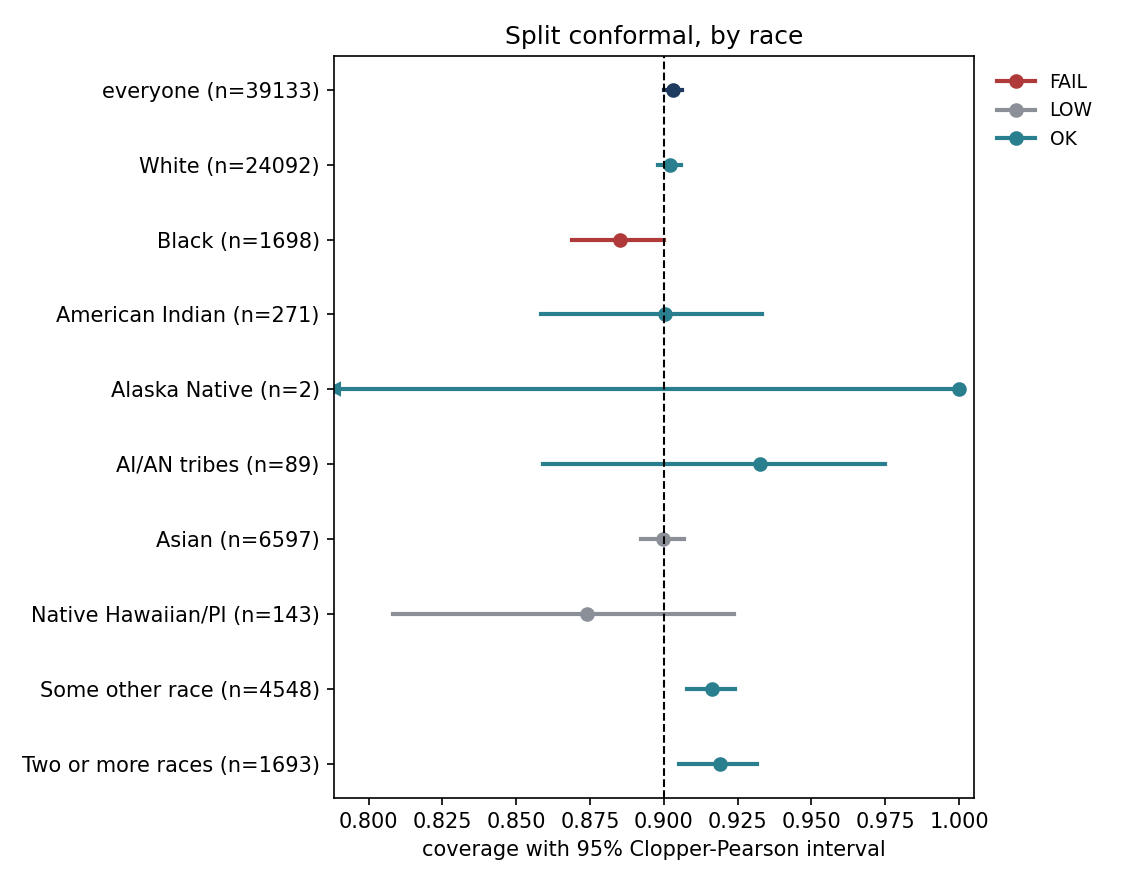

,group,name,n,covered,coverage,ci_low,ci_high,avg_set_size,status
0,ALL,everyone,39133,35345,0.9032,0.9002,0.9061,1.1818,OK
1,1.0,White,24092,21730,0.9020,0.8981,0.9057,1.1839,OK
2,2.0,Black,1698,1503,0.8852,0.8690,0.8999,1.2250,FAIL
3,3.0,American Indian,271,244,0.9004,0.8584,0.9333,1.1624,OK
4,4.0,Alaska Native,2,2,1.0000,0.1581,1.0000,1.0000,OK
5,5.0,AI/AN tribes,89,83,0.9326,0.8590,0.9749,1.2135,OK
6,6.0,Asian,6597,5935,0.8997,0.8921,0.9068,1.1965,LOW
7,7.0,Native Hawaiian/PI,143,125,0.8741,0.8084,0.9237,1.1958,LOW
8,8.0,Some other race,4548,4167,0.9162,0.9078,0.9241,1.1310,OK
9,9.0,Two or more races,1693,1556,0.9191,0.9051,0.9316,1.1878,OK


In [5]:
from IPython.display import Image, display
from covaudit import group_coverage_table
from covaudit.report import plot_group_coverage


def named(table):
    table = table.copy()
    names = ["everyone" if g == "ALL" else RACE_NAMES[int(g)] for g in table["group"]]
    table.insert(1, "name", names)
    return table


g_cal, g_te = X_cal["RAC1P"], X_te["RAC1P"]
split_table = named(group_coverage_table(y_te, split_sets, g_te, model.classes_, alpha=0.1))
display(Image(plot_group_coverage(split_table, 0.1, "/tmp/covaudit_split.png",
                                  title="Split conformal, by race")))
split_table.round(4)

## 5. The repair: Mondrian conformal prediction

Same model and scores, but **one threshold per group**, from that group's own calibration people. Groups with 8 or fewer calibration people get an infinite threshold (every label is kept).

White                threshold 0.6577
Black                threshold 0.6798
American Indian      threshold 0.6443
Alaska Native        threshold inf
AI/AN tribes         threshold 0.5941
Asian                threshold 0.6649
Native Hawaiian/PI   threshold 0.6522
Some other race      threshold 0.6506
Two or more races    threshold 0.6573


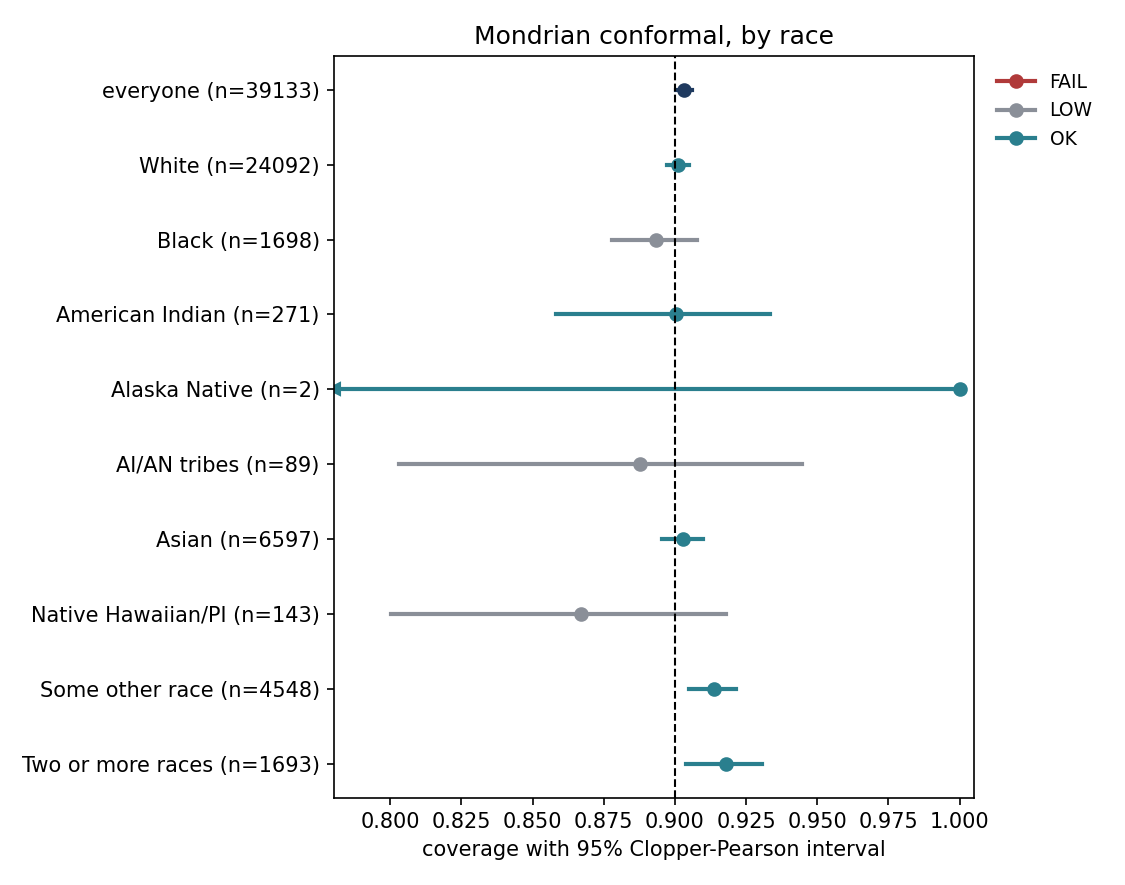

,group,name,n,covered,coverage,ci_low,ci_high,avg_set_size,status
0,ALL,everyone,39133,35344,0.9032,0.9002,0.9061,1.1824,OK
1,1.0,White,24092,21712,0.9012,0.8974,0.9050,1.1825,OK
2,2.0,Black,1698,1517,0.8934,0.8777,0.9077,1.2550,LOW
3,3.0,American Indian,271,244,0.9004,0.8584,0.9333,1.1402,OK
4,4.0,Alaska Native,2,2,1.0000,0.1581,1.0000,2.0000,OK
5,5.0,AI/AN tribes,89,79,0.8876,0.8031,0.9448,1.1124,LOW
6,6.0,Asian,6597,5957,0.9030,0.8956,0.9100,1.2051,OK
7,7.0,Native Hawaiian/PI,143,124,0.8671,0.8003,0.9181,1.1818,LOW
8,8.0,Some other race,4548,4155,0.9136,0.9050,0.9216,1.1245,OK
9,9.0,Two or more races,1693,1554,0.9179,0.9038,0.9305,1.1855,OK


In [6]:
from covaudit import MondrianConformal

mond = MondrianConformal(model, alpha=0.1).calibrate(X_cal, y_cal, g_cal)
for g, t in mond.thresholds_.items():
    print(f"{RACE_NAMES[int(g)]:<20} threshold {t:.4f}")
mond_sets = mond.predict_sets(X_te, g_te)
mond_table = named(group_coverage_table(y_te, mond_sets, g_te, model.classes_, alpha=0.1))
display(Image(plot_group_coverage(mond_table, 0.1, "/tmp/covaudit_mondrian.png",
                                  title="Mondrian conformal, by race")))
mond_table.round(4)

## 6. Side by side

In [7]:
cols = ["group", "name", "n", "coverage", "avg_set_size", "status"]
split_table[cols].merge(mond_table[cols], on=["group", "name", "n"],
                        suffixes=(" split", " mondrian")).round(4)

,group,name,n,coverage split,avg_set_size split,status split,coverage mondrian,avg_set_size mondrian,status mondrian
0,ALL,everyone,39133,0.9032,1.1818,OK,0.9032,1.1824,OK
1,1.0,White,24092,0.9020,1.1839,OK,0.9012,1.1825,OK
2,2.0,Black,1698,0.8852,1.2250,FAIL,0.8934,1.2550,LOW
3,3.0,American Indian,271,0.9004,1.1624,OK,0.9004,1.1402,OK
4,4.0,Alaska Native,2,1.0000,1.0000,OK,1.0000,2.0000,OK
5,5.0,AI/AN tribes,89,0.9326,1.2135,OK,0.8876,1.1124,LOW
6,6.0,Asian,6597,0.8997,1.1965,LOW,0.9030,1.2051,OK
7,7.0,Native Hawaiian/PI,143,0.8741,1.1958,LOW,0.8671,1.1818,LOW
8,8.0,Some other race,4548,0.9162,1.1310,OK,0.9136,1.1245,OK
9,9.0,Two or more races,1693,0.9191,1.1878,OK,0.9179,1.1855,OK


## 7. What one run cannot show

A single split is noisy, especially for small groups. The repository's committed evidence
(`results/`) repeats this over **20 seeds** and also tests other states:

- **20 seeds, by race:** under split, Black (0.892 on average) and Asian (0.897) are
  under-covered and flagged FAIL on 5 and 4 of 20 seeds; Native Hawaiian/PI is lowest
  (0.885) but too small to be flagged. Under Mondrian every group with enough data
  averages 0.900-0.908, at almost no overall cost (average set size 1.1795 -> 1.1803).
- **By sex:** split under-covers men (0.895, FAIL on 12 of 20 seeds) and over-covers
  women (0.906); Mondrian brings both to about 0.90.
- **Distribution shift:** thresholds calibrated in California give only 0.884 (Texas),
  0.884 (New York) and 0.869 (Florida). Mondrian does not fix this.

Full report:
[results/report/report.md](https://github.com/simarsinghlamba/covaudit/blob/main/results/report/report.md)

## Limitations

Mondrian needs each person's group at prediction time; very small groups get
uninformative full sets; it protects only the groups you define; and nothing here
repairs distribution shift.